In [1]:
%load_ext autoreload
%autoreload 2

import collections
import numpy as np
import scipy.stats
import tqdm
import torch
from torch import tensor, Tensor
from typing import Iterable, Any

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import pandas as pd
import seaborn as sns

import block_formats.analysis as A
import block_formats.experiments as E
import block_formats.quantisation as Q
import plot_utils

plot_utils.configure()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


### `kl_fisher_prediction_noise`

In [2]:
fisher_sum = {run.config.model: run.summary.fisher for run in E.runs("20250423-fisher")}
weight_stats = {run.config.model: run.summary.weight_stats for run in E.runs("20250423-weight-stats")}

In [61]:
runs = E.runs("20250502-noise-sensitivity")
display(dict(collections.Counter(run.config.model for run in runs)))

{'meta-llama/Llama-3.2-1B': 339,
 'meta-llama/Llama-3.2-3B': 591,
 'meta-llama/Llama-3.1-8B': 678,
 'google/gemma-3-1b-pt': 549,
 'google/gemma-3-4b-pt': 1209,
 'google/gemma-3-12b-pt': 69,
 'Qwen/Qwen2.5-0.5B': 507,
 'Qwen/Qwen2.5-1.5B': 591,
 'Qwen/Qwen2.5-3B': 154}

In [62]:
def get_row(run: E.AttrDict) -> dict[str, Any]:
    if run.meta.status == "finished" and "vision_model" not in run.config.test.parameter and "multi_modal_projector" not in run.config.test.parameter:
        return dict(
            model=run.config.model.split("/")[1],
            scale=run.config.test.scale,
            parameter=run.config.test.parameter,
            fisher_sum=fisher_sum[run.config.model][run.config.test.parameter],
            rm2=weight_stats[run.config.model][run.config.test.parameter].rm2,
            kl_div=tensor(run.summary.kl_div).mean().item(),
        )

df = pd.DataFrame.from_records(filter(None, map(get_row, runs)))
df["kl_div_prediction"] = 0.5 * (df.scale * df.rm2) ** 2 * df.fisher_sum
df["magnitude_prediction"] = 0.5 * (df.scale * df.rm2) ** 2
df.head()

,model,scale,parameter,fisher_sum,rm2,kl_div,kl_div_prediction,magnitude_prediction
0,Llama-3.2-1B,0.25,model.embed_tokens.weight,7028.244600,0.021907,0.100927,0.105403,0.000015
1,Llama-3.2-1B,0.25,model.layers.0.self_attn.q_proj.weight,7.463257,0.036875,0.001434,0.000317,0.000042
2,Llama-3.2-1B,0.25,model.layers.0.self_attn.k_proj.weight,12.020443,0.047735,0.002423,0.000856,0.000071
3,Llama-3.2-1B,0.25,model.layers.0.self_attn.v_proj.weight,1267.261500,0.009144,0.006154,0.003311,0.000003
4,Llama-3.2-1B,0.25,model.layers.0.self_attn.o_proj.weight,736.610960,0.011592,0.005260,0.003093,0.000004


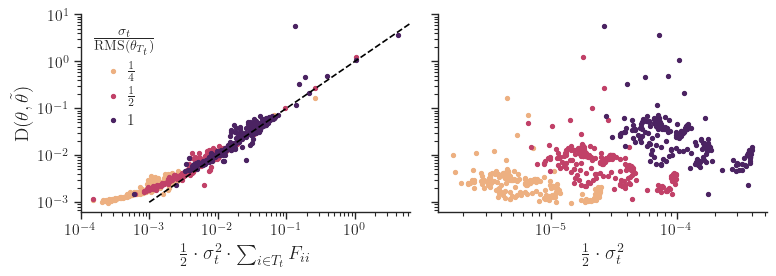

In [ ]:
model = "Llama-3.1-8B"
fig, axs = plt.subplots(ncols=2, sharey=True)
for ax, predictor in zip(axs, ["kl_div_prediction", "magnitude_prediction"]):
    scales = sorted(df.scale.unique())
    for scale, color in zip(scales, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(scales))):
        d = df[(df.model == model) & (df.scale == scale)]
        ax.scatter(d[predictor], d.kl_div, color=color, label=plot_utils.format_fraction()(scale, None))
    if predictor == "kl_div_prediction":
        ax.plot([10**-3, 10], [10**-3, 10], "k--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    if predictor == "kl_div_prediction":
        ax.set_xlabel(r"$\frac{1}{2} \cdot \sigma_t^2 \cdot \sum_{i \in T_t} F_{ii}$")
        ax.set_xlim((10**-4, 10**0.8))
    if predictor == "magnitude_prediction":
        ax.set_xlabel(r"$\frac{1}{2} \cdot \sigma_t^2$")
axs[0].set_ylim((10**-3.2, 10**1))
axs[0].legend(title=r"$\frac{\sigma_t}{\text{RMS}(\theta_{T_t})}$", handletextpad=1., handlelength=0)
axs[0].set_ylabel(r"$\mathrm{D}(\theta, \tilde{\theta})$")
plot_utils.tidy(fig)
plot_utils.save("kl_fisher_prediction_noise")

### `fisher_structure`

Analysis of structure in the diagonal Fisher, to justify the constant-per-tensor approximation

In [ ]:
# Warning: this can take ~2m
fisher = E.fisher.fetch_fisher("meta-llama/Llama-3.1-8B", device=DEVICE)

remote: Updating references: 100% (1/1)           


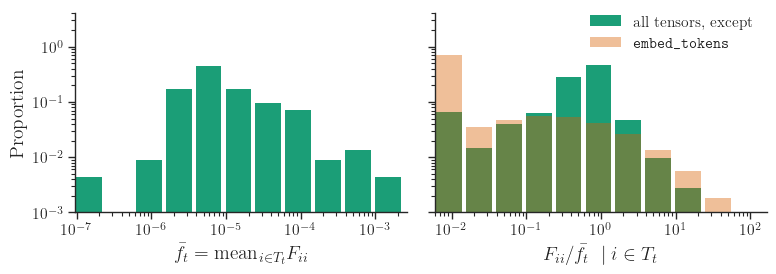

In [233]:
def count_histogram(tensors: Iterable[Tensor], bins: Tensor) -> Tensor:
    boundaries = (bins[1:] + bins[:-1]) / 2
    counts = torch.zeros(len(bins), dtype=torch.int64, device=DEVICE)
    for t in tensors:
        counts += torch.bincount(torch.bucketize(t, boundaries), minlength=len(bins))
    return counts

fig, (ax0, ax1) = plt.subplots(ncols=2, sharey=True)
last_bin_ratio = 0.6  # make sure we clip the last bin, since the bin edges are open
width_ratio = 0.5  # hack
xrange = 4
xstep = 0.4

x0 = -6.8
bins = 10 ** torch.arange(x0, x0 + xrange + 1e-3, xstep, device=DEVICE)
binw = torch.diff(torch.cat([bins, bins[-1:] ** 2 / bins[-2]])).cpu() * width_ratio
counts = count_histogram([torch.stack([t.mean(dtype=torch.float32) for t in fisher.values()])], bins)
counts = counts / counts.sum()
ax0.bar(bins.cpu(), counts.cpu(), width=binw, lw=0)

ax0.set_xscale("log")
ax0.set_xlabel(r"$\bar{f}_t = \mathrm{mean}_{i \in T_t} F_{ii}$")
ax0.set_xlim((bins[0].item() * last_bin_ratio, bins[-1].item() / last_bin_ratio))

bins = 10 ** torch.arange(-xrange/2, xrange/2 + 1e-3, xstep, device=DEVICE)
binw = torch.diff(torch.cat([bins, bins[-1:] ** 2 / bins[-2]])).cpu() * width_ratio
counts = count_histogram((fisher[k].flatten().float() / fisher[k].mean(dtype=torch.float32) for k in fisher if k != "model.embed_tokens.weight"), bins)
counts = counts / counts.sum()
ax1.bar(bins.cpu(), counts.cpu(), width=binw, label="all tensors, except", lw=0)
counts = count_histogram((fisher[k].flatten().float() / fisher[k].mean(dtype=torch.float32) for k in ["model.embed_tokens.weight"]), bins)
counts = counts / counts.sum()
ax1.bar(bins.cpu(), counts.cpu(), width=binw, lw=0, alpha=.4, label=r"\texttt{embed_tokens}")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim((bins[0].item() * last_bin_ratio, bins[-1].item() / last_bin_ratio))
ax1.set_xlabel(r"$F_{ii} / \bar{f}_t \;\mid i \in T_t$")
ax1.legend(loc="upper right", bbox_to_anchor=(1, 1.06))

ax0.set_ylim((10**-3, 4))
ax0.set_ylabel("Proportion")

plot_utils.tidy(fig)
plot_utils.save("fisher_structure")

In [224]:
display(pd.DataFrame.from_dict([dict(tensor=k, fisher_mean=v.mean(dtype=torch.float32).item()) for k, v in fisher.items()]).sort_values("fisher_mean"))

,tensor,fisher_mean
7,model.layers.0.self_attn.q_proj.weight,2.031723e-07
5,model.layers.0.self_attn.k_proj.weight,1.590264e-06
119,model.layers.23.self_attn.q_proj.weight,1.719210e-06
126,model.layers.24.self_attn.q_proj.weight,1.944991e-06
175,model.layers.30.self_attn.q_proj.weight,2.101389e-06
...,...,...
169,model.layers.3.self_attn.v_proj.weight,4.142772e-04
92,model.layers.2.self_attn.v_proj.weight,5.397277e-04
15,model.layers.1.self_attn.v_proj.weight,9.105785e-04
9,model.layers.1.mlp.down_proj.weight,1.001650e-03


In [ ]:
del fisher  # memory!

### `TODO`